In [1]:
from google.colab import drive
drive.mount('/content/drive')
!cp -r /content/drive/MyDrive/illm/splits .
!ls splits

Mounted at /content/drive
guj_Gujr_dev.txt	guj_Gujr_test.txt
guj_Gujr_manifest.json	guj_Gujr_train.txt.gz


# ILLM — Lab 4: N-gram Language Models and Smoothing

**Corpus.** The sentence corpus and the train/dev/test split built in **Lab 3** from IndicCorp v2
(`ai4bharat/IndicCorpV2`). Dev and test are 1000 sentences each; everything else is training data.
This notebook loads those files and verifies them against Lab 3's manifest hash — run Lab 3 first.

**Task.** Build unigram, bigram, trigram and quadgram models (N = 1, 2, 3, 4) and compare their
test-set perplexities under five settings:

| # | Setting | Estimator |
|---|---------|-----------|
| 1 | Unsmoothed (MLE) | $P(w_n\mid w_1^{n-1}) = \dfrac{C(w_1^{n})}{C(w_1^{n-1})}$ |
| 2 | Add-1 / Laplace | $P(w_n\mid w_1^{n-1}) = \dfrac{C(w_1^{n})+1}{C(w_1^{n-1})+V}$ |
| 3 | Add-k, $0<k<1$ | $P(w_n\mid w_1^{n-1}) = \dfrac{C(w_1^{n})+k}{C(w_1^{n-1})+kV}$ |
| 4 | Interpolated | $P_{\text{int}}(w_n\mid w_1^{n-1}) = \lambda_n P_{ML}(w_n\mid w_1^{n-1}) + (1-\lambda_n)P_{\text{int}}(w_n\mid w_2^{n-1})$ |
| 5 | Kneser–Ney, $d=0.75$ | absolute discounting + continuation probabilities |

with the unigram base case given in the assignment:

$$P_{\text{smooth}}(w_i) = \lambda P(w_i) + (1-\lambda)\frac{1}{V}$$

$k$ and the $\lambda$ vector are tuned on the **dev** split; $d$ is fixed at 0.75 as specified.
Nothing is ever tuned on test.

---

### A note on why the counting code looks the way it does

1,000,000 IndicCorp sentences is roughly **20 million tokens**, which yields on the order of
**15 million distinct 4-grams**. A `dict` keyed by Python string-tuples would need ~8 GB for that
and several minutes to build. So the counting engine here maps tokens to integer ids and packs
each n-gram into a **single `uint64`** (16 bits per token, 4 tokens = 64 bits). Counting then
becomes `np.unique`, and probability lookup becomes a vectorised `np.searchsorted` — the whole
corpus is counted in well under a minute and every perplexity is computed on whole arrays rather
than in a Python loop.

Because that machinery is easy to get subtly wrong, §7 re-implements all five estimators in
plain readable Python dictionaries and **asserts that the two agree to floating-point precision**
on a sample. The fast path is an optimisation, not a different model.

### Size presets and caching

The corpus file on the Hub is 47 GB, so nothing is downloaded wholesale: an HTTP stream is read
until `N_SENTENCES` lines have arrived and then closed. Two caches make every run after the first
one cheap:

* the fetched sentences are stored **gzipped** (`.txt.gz`, roughly 4x smaller than raw text);
* the tokenised, integer-encoded splits and the vocabulary are stored in one compressed **`.npz`**,
  so re-running the notebook skips tokenisation altogether.

`PRESET` in the config cell selects the corpus size. Approximate first-run cost for Hindi
(subsequent runs are dominated by the cache load, a few seconds):

| PRESET | sentences | download | first run | peak RAM |
|---|---|---|---|---|
| `full` | 1,000,000 | ~150–250 MB | ~5–8 min | ~3–4 GB |
| `quick` | 100,000 (1 lakh) | ~20 MB | ~1 min | ~0.6 GB |
| `tiny` | 20,000 | ~5 MB | ~20 s | ~0.2 GB |

`full` is the setting the assignment asks for. `quick` is there for iterating — the conclusions
are identical, only the absolute perplexities shift.

### Requirements

`numpy`, `pandas`, `matplotlib`, `requests` (and optionally `datasets`).

## 1. Setup and configuration

In [2]:
import os, io, sys, gc, gzip, json, math, time, random, pickle, hashlib, unicodedata, itertools, resource
from array import array
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 50)

def rss_gb():
    return resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1e6

print("numpy", np.__version__, "| pandas", pd.__version__)

numpy 2.1.3 | pandas 2.2.3


In [3]:
# ==================================================================================
# CONFIGURATION
# ==================================================================================

# ---- corpus ----------------------------------------------------------------------
# The corpus is NOT re-derived here. Lab 3 built the sentence corpus and the
# train/dev/test split; this notebook loads those files and verifies their hash.
LANGUAGE  = "guj_Gujr"           # must match the LANGUAGE used in Lab 3
CACHE_DIR = "."                  # where the preprocessed arrays are cached
N_SENTENCES = None               # filled in from the Lab 3 manifest

# ---- preprocessing ---------------------------------------------------------------
LOWERCASE   = True    # no-op for Indic scripts, matters for Latin-script fragments
STRIP_PUNCT = True    # Unicode categories P* and S* -> whitespace (danda, quotes, emoji, ...)
MIN_COUNT   = 2       # training words below this count become <UNK>
VOCAB_MAX   = 65533   # hard cap so a token id fits in 16 bits (see the packing note in §5)
MIN_LEN     = 1       # drop sentences shorter than this after tokenisation
MAX_LEN     = 200     # drop pathological very long lines

# ---- splits ----------------------------------------------------------------------
# dev and test are exactly 1000 sentences each, fixed by Lab 3 — nothing to configure.
SEED = 42

# ---- models ----------------------------------------------------------------------
MAX_ORDER   = 4       # unigram .. quadgram  (4 is the maximum for 16-bit x 4 = 64-bit packing)
KN_DISCOUNT = 0.75    # d, fixed by the assignment

# ---- tuning (dev split only) -----------------------------------------------------
ADD_K_GRID  = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9]
LAMBDA_GRID = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
TUNE_PASSES = 3       # coordinate-ascent passes over the lambda vector
DEV_TUNE_SENTENCES = 25_000   # dev subsample used for tuning (full dev used for reporting)

# ---- special token ids (BOS must be 0 so zero-padding is free) --------------------
BOS_ID, EOS_ID, UNK_ID = 0, 1, 2
BOS, EOS, UNK = "<s>", "</s>", "<UNK>"

BITS = np.uint64(16)          # bits per token id in a packed n-gram key
assert VOCAB_MAX + 3 <= 1 << 16, "vocabulary must fit in 16 bits"
assert MAX_ORDER * 16 <= 64,     "packing supports at most order 4"

random.seed(SEED)
np.random.seed(SEED)

print(f"language    : {LANGUAGE}  (splits come from Lab 3)")
print(f"orders      : 1..{MAX_ORDER}   |  KN d = {KN_DISCOUNT}")

language    : guj_Gujr  (splits come from Lab 3)
orders      : 1..4   |  KN d = 0.75


## 2. Corpus — the splits built in Lab 3

Lab 4's instructions say to use *the same* corpus and *the same* training, development and test
splits as the previous assignment. So this notebook does not stream, tokenise or split anything —
it loads the three files Lab 3 wrote to `splits/` and checks each one against the SHA-256 recorded
in Lab 3's manifest.

If the hashes match, the two assignments are provably using identical data. If Lab 3 has not been
run yet, this cell fails with a clear message rather than silently inventing a different split.

`dev` and `test` are 1000 sentences each, as the Lab 3 specification requires; everything else is
training data.

In [4]:
# ==================================================================================
# CORPUS — the canonical splits produced by Lab 3
# ==================================================================================
SPLIT_DIR = "splits"
TRAIN_PATH = os.path.join(SPLIT_DIR, f"{LANGUAGE}_train.txt.gz")
DEV_PATH   = os.path.join(SPLIT_DIR, f"{LANGUAGE}_dev.txt")
TEST_PATH  = os.path.join(SPLIT_DIR, f"{LANGUAGE}_test.txt")
MANIFEST   = os.path.join(SPLIT_DIR, f"{LANGUAGE}_manifest.json")


def read_split(path):
    opener = (lambda p: gzip.open(p, "rt", encoding="utf-8")) if path.endswith(".gz") \
             else (lambda p: open(p, encoding="utf-8"))
    with opener(path) as f:
        return [ln.rstrip("\n") for ln in f if ln.strip()]


def sha256_of(lines):
    h = hashlib.sha256()
    for ln in lines:
        h.update(ln.encode("utf-8"))
        h.update(b"\n")
    return h.hexdigest()


missing = [p for p in (TRAIN_PATH, DEV_PATH, TEST_PATH, MANIFEST) if not os.path.exists(p)]
if missing:
    raise FileNotFoundError(
        "Lab 3 output not found: " + ", ".join(missing) +
        "\nRun ILLM_Lab3_Tokenization.ipynb first (with the same LANGUAGE and PRESET); "
        "its section 4 writes these files."
    )

t0 = time.time()
train_raw = read_split(TRAIN_PATH)
dev_raw   = read_split(DEV_PATH)
test_raw  = read_split(TEST_PATH)
lab3 = json.load(open(MANIFEST, encoding="utf-8"))

print(f"Loaded Lab 3 splits in {time.time()-t0:.1f}s")
print(f"  train {len(train_raw):>9,}   dev {len(dev_raw):>6,}   test {len(test_raw):>6,}")

# --- verify we have exactly what Lab 3 wrote -------------------------------------
ok = True
for name, lines in (("train", train_raw), ("dev", dev_raw), ("test", test_raw)):
    expected_n = lab3[f"{name}_sentences"]
    digest = sha256_of(lines)
    match = (len(lines) == expected_n) and (digest == lab3["sha256"][name])
    ok &= match
    print(f"  {name:<5} sha256 {digest[:16]}…  {'verified' if match else 'MISMATCH'}")
assert ok, ("The split files do not match the Lab 3 manifest. Re-run Lab 3, or delete "
            "splits/ and regenerate it.")

print(f"\n✓ verified against {MANIFEST}")
print(f"  Lab 3 preset='{lab3['preset']}' language='{lab3['language']}' "
      f"seed={lab3['seed']} strategy='{lab3['strategy']}'")
if lab3["language"] != LANGUAGE:
    print(f"  WARNING: manifest language {lab3['language']} != LANGUAGE {LANGUAGE}")

raw_sentences = train_raw          # kept for the corpus-size labels used later on
corpus_name = f"lab3:{LANGUAGE}"
N_SENTENCES = lab3["total_sentences"]
SPLIT_HASH = lab3["sha256"]["train"][:10]

print(f"\nSample training sentences:")
for s in train_raw[:3]:
    print("  •", s[:130])
print(f"\nRSS {rss_gb():.2f} GB")

Loaded Lab 3 splits in 3.6s
  train   998,000   dev  1,000   test  1,000
  train sha256 fd0f3fa0e7b0a552…  verified
  dev   sha256 55457a11cce03502…  verified
  test  sha256 2098e7863da45dae…  verified

✓ verified against splits/guj_Gujr_manifest.json
  Lab 3 preset='full' language='guj_Gujr' seed=42 strategy='uniform'

Sample training sentences:
  • આ વીડિયો જુઓ: ઊંઝા માર્કેટયાર્ડ આજથી 25 જુલાઈ સુધી બંધ
  • મિથેનોલ આવ્યો ક્યાંથી?
  • આખરે ત્રણ રાજ્યોમાં મળેલ હાર પર કોંગ્રેસ અધ્યક્ષ રાહુલ ગાંધી દ્વારા પ્રથમ પ્રતિક્રિયા આપવામાં આવી છે.

RSS 0.42 GB


## 3. Preprocessing and tokenization

1. **NFC normalisation** — Devanagari can encode the same grapheme in several ways; without this
   the same word would count as two types.
2. **Strip zero-width joiners** (`U+200B/C/D`, `U+FEFF`) — endemic in web-scraped Indic text.
3. **Punctuation and symbols → whitespace** — every character whose Unicode general category
   starts with `P` or `S`, so the danda `।`, quotes, dashes and emoji all go.
4. **Lowercase** and **whitespace tokenisation**.

Sentences outside `[MIN_LEN, MAX_LEN]` tokens are dropped at encoding time.

Tokenisation is applied lazily rather than materialised as a global list of token lists — at 20M
tokens that list alone would cost well over a gigabyte. The corpus is therefore touched exactly
**twice**: once to count training types, once to encode every split into integer ids. The result
of both passes is cached (next section), so this cost is paid once, not once per run.

In [5]:
class _PunctTable(dict):
    """Lazy Unicode translation table: punctuation/symbol codepoints -> space."""
    def __missing__(self, cp):
        ch = chr(cp)
        v = " " if unicodedata.category(ch)[0] in ("P", "S") else ch
        self[cp] = v
        return v

PUNCT_TABLE = _PunctTable()
ZERO_WIDTH = dict.fromkeys(map(ord, "\u200b\u200c\u200d\ufeff"), None)


def tokenize(sentence):
    s = unicodedata.normalize("NFC", sentence).translate(ZERO_WIDTH)
    if STRIP_PUNCT:
        s = s.translate(PUNCT_TABLE)
    if LOWERCASE:
        s = s.lower()
    return s.split()


demo = raw_sentences[1]
print("RAW :", demo[:140])
print("TOK :", tokenize(demo)[:18])

RAW : મિથેનોલ આવ્યો ક્યાંથી?
TOK : ['મિથેનોલ', 'આવ્યો', 'ક્યાંથી']


## 5. Vocabulary, `<UNK>`, and integer encoding

The vocabulary comes from the **training split only**. Words with fewer than `MIN_COUNT`
occurrences become `<UNK>`, and the vocabulary is additionally capped at the `VOCAB_MAX` most
frequent types.

$$V = |\{\text{kept types}\}| + |\{\texttt{<UNK>}\}| + |\{\texttt{</s>}\}|$$

`<s>` is deliberately **excluded** from $V$: it only ever appears in a context and is never
predicted. Every model predicts exactly `len(sentence) + 1` symbols per sentence (the words plus
`</s>`), which is what makes perplexities comparable across N.

**Why the cap.** Token ids are packed 16 bits each into a `uint64`, so four of them fill the word
exactly and an n-gram becomes a single integer that numpy can sort and binary-search. That
requires ids `< 65536`, hence `VOCAB_MAX = 65533` (plus the three special ids). The `<UNK>` rate
this induces is reported below so the effect is visible rather than hidden.

### The padded stream

Instead of padding separately for each order, the corpus is written once into a single stream
with `MAX_ORDER-1` start symbols before every sentence and `</s>` after it:

```
<s> <s> <s> w1 w2 ... wk </s>   <s> <s> <s> v1 v2 ... </s>   ...
             ^--------------^  positions that get predicted
```

For any order $m \le$ `MAX_ORDER`, the $m$-gram at a predicted position is just the window of
length $m$ ending there — which reproduces exactly the classic "pad with $m-1$ start symbols"
convention, for all four orders at once, from one pass over the data.

In [6]:
def positions_from_lengths(L, pad):
    #  Predicted positions (the words plus </s>) for a stream padded with `pad` start symbols.
    L = np.asarray(L, dtype=np.int64)
    n_pred = L + 1
    seg = pad + L + 1
    starts = np.concatenate(([0], np.cumsum(seg)[:-1])) + pad
    ends = np.cumsum(n_pred)
    return (np.arange(int(ends[-1]))
            - np.repeat(ends - n_pred, n_pred)
            + np.repeat(starts, n_pred))


def count_types(raw_iter):
    # Pass 1 over training text: type counts, using the same length filter as encoding.
    c = Counter()
    for line in raw_iter:
        t = tokenize(line)
        if MIN_LEN <= len(t) <= MAX_LEN:
            c.update(t)
    return c


def encode_split(raw_iter, pad):
    # Pass 2: raw sentences -> uint16 id stream + per-sentence token counts.
    buf, lens = array("H"), array("i")
    get = word2id.get
    for line in raw_iter:
        toks = tokenize(line)
        L = len(toks)
        if L < MIN_LEN or L > MAX_LEN:
            continue
        lens.append(L)
        buf.extend([BOS_ID] * pad)
        for w in toks:
            buf.append(get(w, UNK_ID))
        buf.append(EOS_ID)
    return (np.frombuffer(buf, dtype=np.uint16).copy(),
            np.frombuffer(lens, dtype=np.int32).copy())


def build_stream(raw_iter, pad):
    # Convenience wrapper returning (stream, positions).
    stream, lens = encode_split(raw_iter, pad)
    return stream, positions_from_lengths(lens, pad)


def prep_cache_path():
    # Cache key covers every setting that would change the arrays.
    key = json.dumps([LANGUAGE, SPLIT_HASH, LOWERCASE, STRIP_PUNCT,
                      MIN_COUNT, VOCAB_MAX, MIN_LEN, MAX_LEN,
                      SEED, MAX_ORDER], sort_keys=True)
    tag = hashlib.md5(key.encode()).hexdigest()[:10]
    return os.path.join(CACHE_DIR, f"prep_{LANGUAGE}_{tag}.npz")

### Preprocessed-array cache

Tokenising tens of millions of tokens is the slowest step in the notebook, and nothing about it
changes between runs. So the encoded streams and the vocabulary are written to one compressed
`.npz`, and a second run skips straight past tokenisation.

Only the token ids and the per-sentence lengths are stored. The position arrays are recomputed on
load: they are pure arithmetic on the lengths, and storing them would multiply the file size.

In [7]:
PAD = MAX_ORDER - 1
CACHE = prep_cache_path()
t_start = time.time()
word2id = {}

if os.path.exists(CACHE):
    z = np.load(CACHE)
    kept = str(z["kept_words"][0]).split("\n")
    train_stream, train_lens = z["train_stream"], z["train_lens"]
    dev_stream,   dev_lens   = z["dev_stream"],   z["dev_lens"]
    test_stream,  test_lens  = z["test_stream"],  z["test_lens"]
    coverage = float(z["coverage"][0])
    print(f"Loaded preprocessed arrays from {CACHE} "
          f"({os.path.getsize(CACHE)/1e6:.0f} MB, {time.time()-t_start:.1f}s)")
else:
    t0 = time.time()
    train_counts = count_types(train_raw)
    kept = [w for w, c in train_counts.most_common() if c >= MIN_COUNT][:VOCAB_MAX]
    coverage = sum(train_counts[w] for w in kept) / sum(train_counts.values())
    print(f"  vocabulary pass   {time.time()-t0:6.1f}s")
    del train_counts
    _ = gc.collect()

    word2id = {w: i + 3 for i, w in enumerate(kept)}
    t0 = time.time()
    train_stream, train_lens = encode_split(train_raw, PAD)
    dev_stream,   dev_lens   = encode_split(dev_raw,   PAD)
    test_stream,  test_lens  = encode_split(test_raw,  PAD)
    print(f"  encoding pass     {time.time()-t0:6.1f}s")

    t0 = time.time()
    np.savez_compressed(CACHE,
                        kept_words=np.array(["\n".join(kept)]),
                        coverage=np.array([coverage]),
                        train_stream=train_stream, train_lens=train_lens,
                        dev_stream=dev_stream,     dev_lens=dev_lens,
                        test_stream=test_stream,   test_lens=test_lens)
    print(f"  cached to {CACHE}  ({os.path.getsize(CACHE)/1e6:.0f} MB, {time.time()-t0:.0f}s)")

word2id = {w: i + 3 for i, w in enumerate(kept)}
id2word = {i + 3: w for i, w in enumerate(kept)}
id2word.update({BOS_ID: BOS, EOS_ID: EOS, UNK_ID: UNK})
V = len(kept) + 2

train_pos = positions_from_lengths(train_lens, PAD)
dev_pos   = positions_from_lengths(dev_lens,   PAD)
test_pos  = positions_from_lengths(test_lens,  PAD)

print(f"\nData ready in {time.time()-t_start:.1f}s   |  RSS {rss_gb():.2f} GB")

  vocabulary pass     31.6s
  encoding pass       30.7s
  cached to ./prep_guj_Gujr_fa6d490de0.npz  (26 MB, 3s)

Data ready in 65.7s   |  RSS 0.82 GB


In [8]:
print(f"Kept types        : {len(kept):,}  (count >= {MIN_COUNT}, capped at {VOCAB_MAX:,})")
print(f"Vocabulary size V : {V:,}   (kept types + <UNK> + </s>)")
print(f"Token coverage    : {100*coverage:.2f}%  ->  <UNK> rate on train {100*(1-coverage):.2f}%")

def unk_rate(stream, pos):
    return 100 * float(np.mean(stream[pos] == UNK_ID))

stats = pd.DataFrame([{
    "split": name,
    "sentences": len(lens),
    "tokens": int(lens.sum()),
    "predicted symbols": len(pos),
    "mean length": round(float(lens.mean()), 1),
    "<UNK> %": round(unk_rate(stream, pos), 2),
} for name, stream, lens, pos in [
    ("train", train_stream, train_lens, train_pos),
    ("dev",   dev_stream,   dev_lens,   dev_pos),
    ("test",  test_stream,  test_lens,  test_pos),
]])
display(stats.set_index("split"))
print(f"RSS {rss_gb():.2f} GB")

Kept types        : 65,533  (count >= 2, capped at 65,533)
Vocabulary size V : 65,535   (kept types + <UNK> + </s>)
Token coverage    : 93.65%  ->  <UNK> rate on train 6.35%


,sentences,tokens,predicted symbols,mean length,<UNK> %
split,,,,,
train,997986,15210546,16208532,15.2,5.96
dev,1000,29821,30821,29.8,6.96
test,1000,29886,30886,29.9,6.91


RSS 0.82 GB


## 6. The counting engine

`Table` holds one order's counts as three parallel sorted arrays and derives, by aggregating the
n-gram table itself, the two quantities every smoothing method needs:

* $C(w_1^{m-1}) = \sum_w C(w_1^{m-1}w)$ — the context count (derived, so numerator and
  denominator can never disagree about padding),
* $N_{1+}(w_1^{m-1}\bullet) = |\{w : C(w_1^{m-1}w) > 0\}|$ — the number of distinct continuations,
  which is the discount mass Kneser–Ney redistributes.

`Table.from_continuation` builds the **continuation counts** that Kneser–Ney uses at the lower
orders: $N_{1+}(\bullet\,w_2^{m}) = |\{v : C(v\,w_2^{m}) > 0\}|$. Because two distinct
$(m{+}1)$-grams sharing a suffix must differ in their first token, this is simply "how many
distinct $(m{+}1)$-grams end with this $m$-gram" — i.e. masking off the leading 16 bits and
counting duplicates.

In [9]:
def mask_for(m):
    return np.uint64((1 << (16 * m)) - 1)


def pack(stream, pos, order):
    """Pack the order-length window ending at each position into one uint64."""
    k = np.zeros(len(pos), dtype=np.uint64)
    off = order - 1
    for j in range(order):
        k = (k << BITS) | stream[pos - off + j].astype(np.uint64)
    return k


class Table:
    """Sorted packed-key count table plus derived context aggregates."""
    __slots__ = ("gram_keys", "gram_counts", "ctx_keys", "ctx_counts", "ctx_n1p")

    def __init__(self, keys):
        self.gram_keys, counts = np.unique(keys, return_counts=True)
        self.gram_counts = counts.astype(np.int64)
        self._derive()

    @classmethod
    def from_continuation(cls, higher_gram_keys, m):
        """N1+(• gram): distinct predecessors, from the distinct (m+1)-grams."""
        obj = cls.__new__(cls)
        obj.gram_keys, counts = np.unique(higher_gram_keys & mask_for(m), return_counts=True)
        obj.gram_counts = counts.astype(np.int64)
        obj._derive()
        return obj

    def _derive(self):
        ctx = self.gram_keys >> BITS
        self.ctx_keys, inv = np.unique(ctx, return_inverse=True)
        inv = inv.ravel()
        self.ctx_counts = np.bincount(inv, weights=self.gram_counts).astype(np.int64)
        self.ctx_n1p = np.bincount(inv).astype(np.int64)

    def nbytes(self):
        return sum(a.nbytes for a in (self.gram_keys, self.gram_counts,
                                      self.ctx_keys, self.ctx_counts, self.ctx_n1p))


def lookup(sorted_keys, values, q):
    """Vectorised exact lookup; missing keys return 0."""
    if len(sorted_keys) == 0:
        return np.zeros(len(q), dtype=np.int64)
    i = np.searchsorted(sorted_keys, q)
    np.clip(i, 0, len(sorted_keys) - 1, out=i)
    return np.where(sorted_keys[i] == q, values[i], 0)


class NgramStore:
    """Counts for every order 1..max_order, plus KN continuation tables."""

    def __init__(self, stream, pos, max_order, V, d=KN_DISCOUNT):
        self.max_order, self.V, self.d = max_order, V, d
        top = pack(stream, pos, max_order)
        self.tables = {max_order: Table(top)}
        for m in range(max_order - 1, 0, -1):
            self.tables[m] = Table(top & mask_for(m))
        del top
        gc.collect()
        self.cont = {m: Table.from_continuation(self.tables[m + 1].gram_keys, m)
                     for m in range(1, max_order)}
        self.total_tokens = int(self.tables[1].ctx_counts[0])

    def nbytes(self):
        return sum(t.nbytes() for t in self.tables.values()) + \
               sum(t.nbytes() for t in self.cont.values())

In [10]:
t0 = time.time()
store = NgramStore(train_stream, train_pos, MAX_ORDER, V)
print(f"Counted orders 1..{MAX_ORDER} in {time.time()-t0:.0f}s   |  "
      f"tables {store.nbytes()/1e9:.2f} GB  |  RSS {rss_gb():.2f} GB\n")

tbl = pd.DataFrame([{
    "order": m,
    "distinct n-grams": len(store.tables[m].gram_keys),
    "distinct contexts": len(store.tables[m].ctx_keys),
    "singleton %": round(100 * float(np.mean(store.tables[m].gram_counts == 1)), 1),
} for m in range(1, MAX_ORDER + 1)])
print(f"Running tokens in training (incl. </s>): {store.total_tokens:,}")
tbl

Counted orders 1..4 in 7s   |  tables 1.11 GB  |  RSS 2.23 GB

Running tokens in training (incl. </s>): 16,208,532


,order,distinct n-grams,distinct contexts,singleton %
0,1,65535,1,0.0
1,2,4246098,65535,71.2
2,3,10014623,4224147,87.9
3,4,12830331,9826142,94.3


## 7. The five estimators

All five are written against arrays of packed keys, so a whole split is scored in one shot.

**Unseen contexts.** For interpolation and Kneser–Ney, a context with $C(w_1^{m-1}) = 0$ carries
no information, so that level is skipped entirely and the estimate falls through to the level
below. Skipping (rather than contributing a zero MLE term) is what keeps the distribution
normalised — verified numerically in §11.

**Kneser–Ney.** The recursion is evaluated bottom-up. The highest order uses raw counts; every
lower order uses continuation counts; the base case interpolates with the uniform $1/V$:

$$P_{KN}(w \mid u) = \frac{\max(c(u,w)-d,\,0)}{c(u)} + \frac{d\,N_{1+}(u\bullet)}{c(u)}\,P_{KN}(w \mid u')$$

In [11]:
class FastLM:
    """Vectorised n-gram LM of a given order, backed by a shared NgramStore."""

    def __init__(self, store, order):
        self.s, self.N, self.V, self.d = store, order, store.V, store.d

    # ---------- helpers ----------
    def _g(self, t, keys):                       # n-gram count
        return lookup(t.gram_keys, t.gram_counts, keys)

    def _c(self, t, keys, which="ctx_counts"):   # context count / N1+(ctx •)
        return lookup(t.ctx_keys, getattr(t, which), keys >> BITS)

    # ---------- 1. unsmoothed MLE ----------
    def p_mle(self, keys):
        t = self.s.tables[self.N]
        c = self._c(t, keys)
        return np.where(c > 0, self._g(t, keys) / np.maximum(c, 1), 0.0)

    # ---------- 2 & 3. add-k (k = 1 gives Laplace) ----------
    def addk_terms(self, keys):
        """Precompute the count pair once so a whole grid of k costs almost nothing."""
        t = self.s.tables[self.N]
        return self._g(t, keys), self._c(t, keys)

    @staticmethod
    def p_addk_from(terms, k, V):
        g, c = terms
        return (g + k) / (c + k * V)

    def p_addk(self, keys, k):
        return self.p_addk_from(self.addk_terms(keys), k, self.V)

    # ---------- 4. interpolation (Jelinek-Mercer) ----------
    def interp_terms(self, keys):
        """Per-level MLE probability + 'context was seen' mask; independent of lambda."""
        terms = []
        for m in range(1, self.N + 1):
            km = keys & mask_for(m)
            t = self.s.tables[m]
            if m == 1:
                terms.append((None, self._g(t, km) / self.s.total_tokens))
            else:
                c = self._c(t, km)
                seen = c > 0
                terms.append((seen, np.where(seen, self._g(t, km) / np.maximum(c, 1), 0.0)))
        return terms

    def p_interp_from(self, terms, lam):
        p = lam[0] * terms[0][1] + (1.0 - lam[0]) / self.V
        for m in range(2, self.N + 1):
            seen, pml = terms[m - 1]
            p = np.where(seen, lam[m - 1] * pml + (1.0 - lam[m - 1]) * p, p)
        return p

    def p_interp(self, keys, lam):
        return self.p_interp_from(self.interp_terms(keys), lam)

    # ---------- 5. interpolated Kneser-Ney ----------
    def p_kn(self, keys):
        p = np.full(len(keys), 1.0 / self.V)          # base: uniform
        for m in range(1, self.N + 1):
            km = keys & mask_for(m)
            highest = (m == self.N)
            t = self.s.tables[m] if highest else self.s.cont[m]
            den = self._c(t, km)
            safe = np.maximum(den, 1)
            nr = self._c(t, km, "ctx_n1p")
            new = np.maximum(self._g(t, km) - self.d, 0.0) / safe + (self.d * nr / safe) * p
            p = np.where(den > 0, new, p)             # unseen context -> fall through
        return p


def perplexity(p):
    if np.any(p <= 0):
        return float("inf")
    return float(np.exp(-np.mean(np.log(p))))


def zero_stats(p):
    z = int(np.sum(p <= 0))
    covered = p[p > 0]
    return {
        "zero_frac": z / len(p),
        "pp_covered": float(np.exp(-np.mean(np.log(covered)))) if len(covered) else float("inf"),
    }

## 8. Correctness check against a plain-Python reference

The cell below re-implements all five estimators with ordinary dictionaries and string tuples —
slow, but a direct transcription of the formulas — and asserts that it agrees with the vectorised
engine on a sample of test n-grams, for **every order and every method**.

In [12]:
def count_ngrams_ref(order, sentences):
    ng = defaultdict(int)
    pad = [BOS] * (order - 1)
    for toks in sentences:
        seq = pad + toks + [EOS]
        for i in range(order - 1, len(seq)):
            ng[tuple(seq[i - order + 1:i + 1])] += 1
    ctx = defaultdict(int)
    for g, c in ng.items():
        ctx[g[:-1]] += c
    return dict(ng), dict(ctx)


class RefLM:
    """Readable reference implementation — the formulas, written out literally."""

    def __init__(self, order, train_sents, V, d=KN_DISCOUNT):
        self.order, self.V, self.d = order, V, d
        self.ngrams, self.contexts = {}, {}
        for m in range(1, order + 1):
            self.ngrams[m], self.contexts[m] = count_ngrams_ref(m, train_sents)
        self.total_tokens = self.contexts[1][()]
        self.n1p_right = {}
        for m in range(1, order + 1):
            r = defaultdict(int)
            for g in self.ngrams[m]:
                r[g[:-1]] += 1
            self.n1p_right[m] = dict(r)
        self.cont, self.cont_ctx, self.cont_right = {}, {}, {}
        for m in range(order - 1, 0, -1):
            c = defaultdict(int)
            for g in self.ngrams[m + 1]:
                c[g[1:]] += 1
            cc, cr = defaultdict(int), defaultdict(int)
            for g, v in c.items():
                cc[g[:-1]] += v
                cr[g[:-1]] += 1
            self.cont[m], self.cont_ctx[m], self.cont_right[m] = dict(c), dict(cc), dict(cr)

    def p_mle(self, g):
        den = self.contexts[self.order].get(g[:-1], 0)
        return 0.0 if den == 0 else self.ngrams[self.order].get(g, 0) / den

    def p_addk(self, g, k):
        return (self.ngrams[self.order].get(g, 0) + k) / \
               (self.contexts[self.order].get(g[:-1], 0) + k * self.V)

    def p_interp(self, g, lam, m=None):
        if m is None:
            m = self.order
        if m == 1:
            return lam[0] * self.ngrams[1].get(g, 0) / self.total_tokens + (1 - lam[0]) / self.V
        low = self.p_interp(g[1:], lam, m - 1)
        den = self.contexts[m].get(g[:-1], 0)
        if den == 0:
            return low
        return lam[m - 1] * self.ngrams[m].get(g, 0) / den + (1 - lam[m - 1]) * low

    def p_kn(self, g, m=None, highest=True):
        if m is None:
            m = self.order
        ctx = g[:-1]
        if highest:
            den, cnt = self.contexts[m].get(ctx, 0), self.ngrams[m].get(g, 0)
            nr = self.n1p_right[m].get(ctx, 0)
        else:
            den, cnt = self.cont_ctx[m].get(ctx, 0), self.cont[m].get(g, 0)
            nr = self.cont_right[m].get(ctx, 0)
        if den == 0:
            return self.p_kn(g[1:], m - 1, False) if m > 1 else 1.0 / self.V
        low = (1.0 / self.V) if m == 1 else self.p_kn(g[1:], m - 1, False)
        return max(cnt - self.d, 0) / den + (self.d * nr / den) * low

In [13]:
# --- run the comparison on a small slice (the reference is O(minutes) on the full corpus) ---
REF_TRAIN, REF_TEST = 20_000, 300
kept_set = set(kept)

def to_words(raw):
    """Same filtering as encode_split, so the two paths see identical sentences."""
    out = []
    for s in raw:
        t = tokenize(s)
        if MIN_LEN <= len(t) <= MAX_LEN:
            out.append([w if w in kept_set else UNK for w in t])
    return out

ref_train_words = to_words(train_raw[:REF_TRAIN])
ref_test_words  = to_words(test_raw[:REF_TEST])

ref_stream, ref_pos = build_stream(train_raw[:REF_TRAIN], PAD)
ref_store = NgramStore(ref_stream, ref_pos, MAX_ORDER, V)

LAM_TEST = {1: [0.9], 2: [0.9, 0.5], 3: [0.9, 0.5, 0.3], 4: [0.9, 0.5, 0.3, 0.2]}
rows, worst = [], 0.0
for N in range(1, MAX_ORDER + 1):
    fast = FastLM(ref_store, N)
    ref = RefLM(N, ref_train_words, V)
    s_, p_ = build_stream(test_raw[:REF_TEST], N - 1)
    keys = pack(s_, p_, N)

    grams, pad = [], [BOS] * (N - 1)
    for toks in ref_test_words:
        seq = pad + toks + [EOS]
        for i in range(N - 1, len(seq)):
            grams.append(tuple(seq[i - N + 1:i + 1]))
    assert len(grams) == len(keys), (len(grams), len(keys))

    for name, fp, rp in [
        ("MLE",          fast.p_mle(keys),                  [ref.p_mle(g) for g in grams]),
        ("Add-1",        fast.p_addk(keys, 1.0),            [ref.p_addk(g, 1.0) for g in grams]),
        ("Add-k",        fast.p_addk(keys, 0.01),           [ref.p_addk(g, 0.01) for g in grams]),
        ("Interpolated", fast.p_interp(keys, LAM_TEST[N]),  [ref.p_interp(g, LAM_TEST[N]) for g in grams]),
        ("Kneser-Ney",   fast.p_kn(keys),                   [ref.p_kn(g) for g in grams]),
    ]:
        diff = float(np.max(np.abs(np.asarray(fp) - np.asarray(rp))))
        worst = max(worst, diff)
        rows.append({"N": N, "method": name, "max_abs_diff": diff})

display(pd.DataFrame(rows).pivot(index="method", columns="N", values="max_abs_diff"))
assert worst < 1e-12, f"vectorised engine disagrees with the reference (max diff {worst})"
print(f"\n✓ vectorised engine matches the reference implementation "
      f"(worst disagreement {worst:.2e}) across all {len(rows)} model/method combinations.")

del ref_store, ref_train_words, ref_test_words, ref_stream, ref_pos
_ = gc.collect()

N,1,2,3,4
method,,,,
Add-1,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
Add-k,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
Interpolated,6.938894e-18,2.775558e-17,1.110223e-16,1.110223e-16
Kneser-Ney,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
MLE,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00



✓ vectorised engine matches the reference implementation (worst disagreement 1.11e-16) across all 20 model/method combinations.


## 9. Perplexity

$$\text{PP}(W) = \exp\!\left(-\frac{1}{M}\sum_{i=1}^{M}\log P(w_i \mid \text{context})\right)$$

$M$ counts the predicted symbols only: the words of each sentence plus its `</s>`. `<s>` is
never predicted and never counted. Everything is done in log space.

A uniform model must score exactly $V$ — checked below.

In [14]:
uniform_pp = perplexity(np.full(1000, 1.0 / V))
print(f"Uniform-model perplexity {uniform_pp:,.4f}  vs  V = {V:,}   "
      f"{'✓' if abs(uniform_pp - V) < 1e-6 else '✗'}")

# packed keys for each split, at the top order (lower orders are derived by masking)
dev_keys_full  = pack(dev_stream,  dev_pos,  MAX_ORDER)
test_keys_full = pack(test_stream, test_pos, MAX_ORDER)

n_tune = min(DEV_TUNE_SENTENCES, len(dev_raw))
tune_stream, tune_pos = build_stream(dev_raw[:n_tune], PAD)
tune_keys_full = pack(tune_stream, tune_pos, MAX_ORDER)

print(f"dev n-grams  {len(dev_keys_full):,} | test n-grams {len(test_keys_full):,} | "
      f"tuning subset {len(tune_keys_full):,}")
print(f"RSS {rss_gb():.2f} GB")

Uniform-model perplexity 65,535.0000  vs  V = 65,535   ✓
dev n-grams  30,821 | test n-grams 30,886 | tuning subset 30,821
RSS 2.23 GB


## 10. Hyper-parameter tuning on the dev split

* **$k$** for add-k: grid search over `ADD_K_GRID` (every value satisfies $0 < k < 1$).
* **$\lambda$**: one per level, by coordinate ascent — repeatedly fix all levels but one and take
  the grid value that minimises dev perplexity. `lambdas[0]` is the unigram $\lambda$ from the
  assignment's formula; `lambdas[m-1]` weights the order-$m$ MLE against everything below it.

Both searches reuse the precomputed count arrays, so evaluating a candidate is pure arithmetic
on already-fetched numbers rather than a fresh pass over the tables.

In [15]:
best_k, best_lambdas, k_curves = {}, {}, {}

for N in range(1, MAX_ORDER + 1):
    t0 = time.time()
    lm = FastLM(store, N)
    keys = tune_keys_full & mask_for(N)

    # --- add-k ---
    at = lm.addk_terms(keys)
    curve = [(k, perplexity(FastLM.p_addk_from(at, k, V))) for k in ADD_K_GRID]
    best_k[N] = min(curve, key=lambda r: r[1])[0]
    k_curves[N] = pd.DataFrame(curve, columns=["k", "dev_pp"])

    # --- lambdas ---
    it = lm.interp_terms(keys)
    lam = [0.5] * N
    best_pp = perplexity(lm.p_interp_from(it, lam))
    for _ in range(TUNE_PASSES):
        improved = False
        for lvl in range(N):
            cur = lam[lvl]
            for cand in LAMBDA_GRID:
                lam[lvl] = cand
                pp = perplexity(lm.p_interp_from(it, lam))
                if pp < best_pp - 1e-9:
                    best_pp, cur, improved = pp, cand, True
            lam[lvl] = cur
        if not improved:
            break
    best_lambdas[N] = lam

    print(f"N={N}:  k* = {best_k[N]:<8}  lambda* = [{', '.join(f'{x:.2f}' for x in lam)}]"
          f"   dev PP {best_pp:,.2f}   [{time.time()-t0:.1f}s]")
    del at, it
    gc.collect()

N=1:  k* = 0.5       lambda* = [0.95]   dev PP 2,964.61   [0.0s]
N=2:  k* = 0.005     lambda* = [0.80, 0.70]   dev PP 555.68   [0.1s]
N=3:  k* = 0.0005    lambda* = [0.80, 0.60, 0.30]   dev PP 464.41   [0.2s]
N=4:  k* = 0.0005    lambda* = [0.80, 0.60, 0.20, 0.20]   dev PP 447.36   [0.3s]


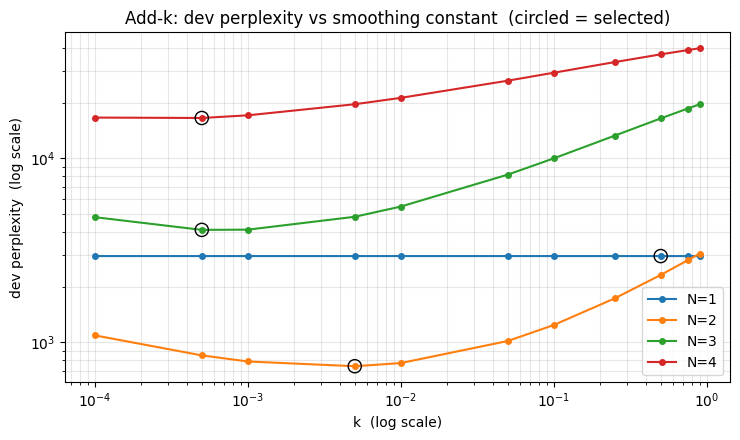

,k,dev_pp
0,0.0001,1091.328461
1,0.0005,849.636134
2,0.0010,787.155084
3,0.0050,741.773463
4,0.0100,771.804579
5,0.0500,1016.867160
6,0.1000,1242.629572
7,0.2500,1734.001956
8,0.5000,2325.211285
9,0.7500,2792.868246


In [16]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for N in range(1, MAX_ORDER + 1):
    ax.plot(k_curves[N].k, k_curves[N].dev_pp, marker="o", ms=4, label=f"N={N}")
    ax.scatter([best_k[N]], [k_curves[N].dev_pp.min()], s=90, zorder=5,
               facecolors="none", edgecolors="k")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("k  (log scale)"); ax.set_ylabel("dev perplexity  (log scale)")
ax.set_title("Add-k: dev perplexity vs smoothing constant  (circled = selected)")
ax.legend(); ax.grid(alpha=.3, which="both")
plt.tight_layout(); plt.show()

k_curves[min(2, MAX_ORDER)]

## 11. Sanity check — do the smoothed distributions sum to 1?

A smoothing scheme is only valid if $\sum_{w \in V} P(w \mid \text{context}) = 1$ for every
context, seen or unseen. This is checked exactly, by summing over the whole vocabulary.

In [17]:
predictable_ids = np.concatenate(([EOS_ID, UNK_ID], np.arange(3, 3 + len(kept)))).astype(np.uint64)
assert len(predictable_ids) == V

def normalisation_row(N, ctx_ids):
    ctx_key = np.uint64(0)
    for t in ctx_ids:
        ctx_key = (ctx_key << BITS) | np.uint64(t)
    keys = (np.uint64(ctx_key) << BITS) | predictable_ids
    lm = FastLM(store, N)
    return {
        "Add-1":        float(lm.p_addk(keys, 1.0).sum()),
        "Add-k":        float(lm.p_addk(keys, best_k[N]).sum()),
        "Interpolated": float(lm.p_interp(keys, best_lambdas[N]).sum()),
        "Kneser-Ney":   float(lm.p_kn(keys).sum()),
    }

N_CHK = min(3, MAX_ORDER)
top_ctx = store.tables[N_CHK].ctx_keys[np.argmax(store.tables[N_CHK].ctx_counts)]
seen_ids = [int((int(top_ctx) >> (16 * j)) & 0xFFFF) for j in range(N_CHK - 2, -1, -1)]
unseen_ids = [UNK_ID] * (N_CHK - 1)

chk = pd.DataFrame({
    f"most frequent context {tuple(id2word.get(i, '?') for i in seen_ids)}":
        normalisation_row(N_CHK, seen_ids),
    "an unseen/rare context": normalisation_row(N_CHK, unseen_ids),
}).T
print(f"Sum of P(w | context) over all {V:,} predictable symbols, order N={N_CHK}")
display(chk.round(9))
print("Every entry should be 1.0 up to floating-point error.")

Sum of P(w | context) over all 65,535 predictable symbols, order N=3


,Add-1,Add-k,Interpolated,Kneser-Ney
"most frequent context ('<s>', '<s>')",1.0,1.0,1.0,1.0
an unseen/rare context,1.0,1.0,1.0,1.0


Every entry should be 1.0 up to floating-point error.


## 12. Full evaluation — 4 orders × 5 settings

Each model is scored on the held-out **test** split using the hyper-parameters selected on dev.

In [18]:
records = []
for N in range(1, MAX_ORDER + 1):
    lm = FastLM(store, N)
    dk = dev_keys_full & mask_for(N)
    tk = test_keys_full & mask_for(N)

    at_d, at_t = lm.addk_terms(dk), lm.addk_terms(tk)
    it_d, it_t = lm.interp_terms(dk), lm.interp_terms(tk)

    variants = [
        ("Unsmoothed (MLE)",              lambda: lm.p_mle(dk),                        lambda: lm.p_mle(tk)),
        ("Add-1 (Laplace)",               lambda: FastLM.p_addk_from(at_d, 1.0, V),    lambda: FastLM.p_addk_from(at_t, 1.0, V)),
        (f"Add-k (k={best_k[N]})",        lambda: FastLM.p_addk_from(at_d, best_k[N], V),
                                          lambda: FastLM.p_addk_from(at_t, best_k[N], V)),
        ("Interpolated (JM)",             lambda: lm.p_interp_from(it_d, best_lambdas[N]),
                                          lambda: lm.p_interp_from(it_t, best_lambdas[N])),
        (f"Kneser-Ney (d={KN_DISCOUNT})", lambda: lm.p_kn(dk),                         lambda: lm.p_kn(tk)),
    ]

    for label, devfn, testfn in variants:
        t0 = time.time()
        pd_dev, pd_test = devfn(), testfn()
        st = zero_stats(pd_test)
        short = label.split(" (k=")[0]
        records.append({
            "N": N,
            "order": {1: "unigram", 2: "bigram", 3: "trigram", 4: "quadgram"}[N],
            "method": short, "label": label,
            "dev_pp": perplexity(pd_dev), "test_pp": perplexity(pd_test),
            "zero_frac": st["zero_frac"], "test_pp_covered": st["pp_covered"],
            "secs": round(time.time() - t0, 2),
        })
        print(f"N={N}  {label:<26} dev {records[-1]['dev_pp']:>12,.2f}"
              f"   test {records[-1]['test_pp']:>12,.2f}"
              f"   zeros {100*st['zero_frac']:6.2f}%   [{records[-1]['secs']:.1f}s]")
    del at_d, at_t, it_d, it_t
    gc.collect()

results = pd.DataFrame(records)
print(f"\nRSS {rss_gb():.2f} GB")

N=1  Unsmoothed (MLE)           dev     2,944.61   test     2,884.78   zeros   0.00%   [0.0s]
N=1  Add-1 (Laplace)            dev     2,944.57   test     2,884.56   zeros   0.00%   [0.0s]
N=1  Add-k (k=0.5)              dev     2,944.54   test     2,884.62   zeros   0.00%   [0.0s]
N=1  Interpolated (JM)          dev     2,964.61   test     2,902.54   zeros   0.00%   [0.0s]
N=1  Kneser-Ney (d=0.75)        dev     2,944.61   test     2,884.78   zeros   0.00%   [0.0s]
N=2  Unsmoothed (MLE)           dev          inf   test          inf   zeros  19.50%   [0.0s]
N=2  Add-1 (Laplace)            dev     3,191.95   test     3,055.79   zeros   0.00%   [0.0s]
N=2  Add-k (k=0.005)            dev       741.77   test       710.82   zeros   0.00%   [0.0s]
N=2  Interpolated (JM)          dev       555.68   test       539.50   zeros   0.00%   [0.0s]
N=2  Kneser-Ney (d=0.75)        dev       487.62   test       473.26   zeros   0.00%   [0.1s]
N=3  Unsmoothed (MLE)           dev          inf   test     

### 12.1 Results

In [19]:
COLS = ["unigram", "bigram", "trigram", "quadgram"][:MAX_ORDER]
ROWS = ["Unsmoothed (MLE)", "Add-1 (Laplace)", "Add-k",
        "Interpolated (JM)", f"Kneser-Ney (d={KN_DISCOUNT})"]

pivot = results.pivot(index="method", columns="order", values="test_pp").reindex(index=ROWS, columns=COLS)
dev_pivot = results.pivot(index="method", columns="order", values="dev_pp").reindex(index=ROWS, columns=COLS)
zero_pivot = (results.pivot(index="method", columns="order", values="zero_frac") * 100).reindex(index=ROWS, columns=COLS)

print(f"TEST PERPLEXITY — {corpus_name} | {N_SENTENCES:,} sentences | V = {V:,} | "
      f"{len(test_keys_full):,} test n-grams scored")
display(pivot.round(2))

print("\nDEV PERPLEXITY (model selection only)")
display(dev_pivot.round(2))

print("\n% of TEST n-grams receiving ZERO probability")
display(zero_pivot.round(2))

mle = results[results.method == "Unsmoothed (MLE)"]
print("\nUnsmoothed model, restricted to the n-grams it can score at all (diagnostic, NOT a perplexity):")
display(mle[["order", "zero_frac", "test_pp_covered"]]
        .assign(**{"zero %": (mle.zero_frac * 100).round(2)})
        .drop(columns="zero_frac")
        .rename(columns={"test_pp_covered": "PP on covered n-grams"}).round(2)
        .set_index("order"))

hp = pd.DataFrame({"N": list(best_k), "k*": [best_k[N] for N in best_k],
                   "lambda*": [", ".join(f"{x:.2f}" for x in best_lambdas[N]) for N in best_k]})
print("\nSelected hyper-parameters (dev):")
display(hp.set_index("N"))

TEST PERPLEXITY — lab3:guj_Gujr | 1,000,000 sentences | V = 65,535 | 30,886 test n-grams scored


order,unigram,bigram,trigram,quadgram
method,,,,
Unsmoothed (MLE),2884.78,inf,inf,inf
Add-1 (Laplace),2884.56,3055.79,19670.62,39497.38
Add-k,2884.62,710.82,3923.54,15686.87
Interpolated (JM),2902.54,539.50,448.72,431.08
Kneser-Ney (d=0.75),2884.78,473.26,393.41,393.23



DEV PERPLEXITY (model selection only)


order,unigram,bigram,trigram,quadgram
method,,,,
Unsmoothed (MLE),2944.61,inf,inf,inf
Add-1 (Laplace),2944.57,3191.95,20314.96,40226.19
Add-k,2944.54,741.77,4087.07,16581.92
Interpolated (JM),2964.61,555.68,464.41,447.36
Kneser-Ney (d=0.75),2944.61,487.62,407.45,408.74



% of TEST n-grams receiving ZERO probability


order,unigram,bigram,trigram,quadgram
method,,,,
Unsmoothed (MLE),0.0,19.5,57.45,79.19
Add-1 (Laplace),0.0,0.0,0.00,0.00
Add-k,0.0,0.0,0.00,0.00
Interpolated (JM),0.0,0.0,0.00,0.00
Kneser-Ney (d=0.75),0.0,0.0,0.00,0.00



Unsmoothed model, restricted to the n-grams it can score at all (diagnostic, NOT a perplexity):


,PP on covered n-grams,zero %
order,,
unigram,2884.78,0.00
bigram,124.57,19.50
trigram,21.09,57.45
quadgram,13.25,79.19



Selected hyper-parameters (dev):


,k*,lambda*
N,,
1,0.5000,0.95
2,0.0050,"0.80, 0.70"
3,0.0005,"0.80, 0.60, 0.30"
4,0.0005,"0.80, 0.60, 0.20, 0.20"


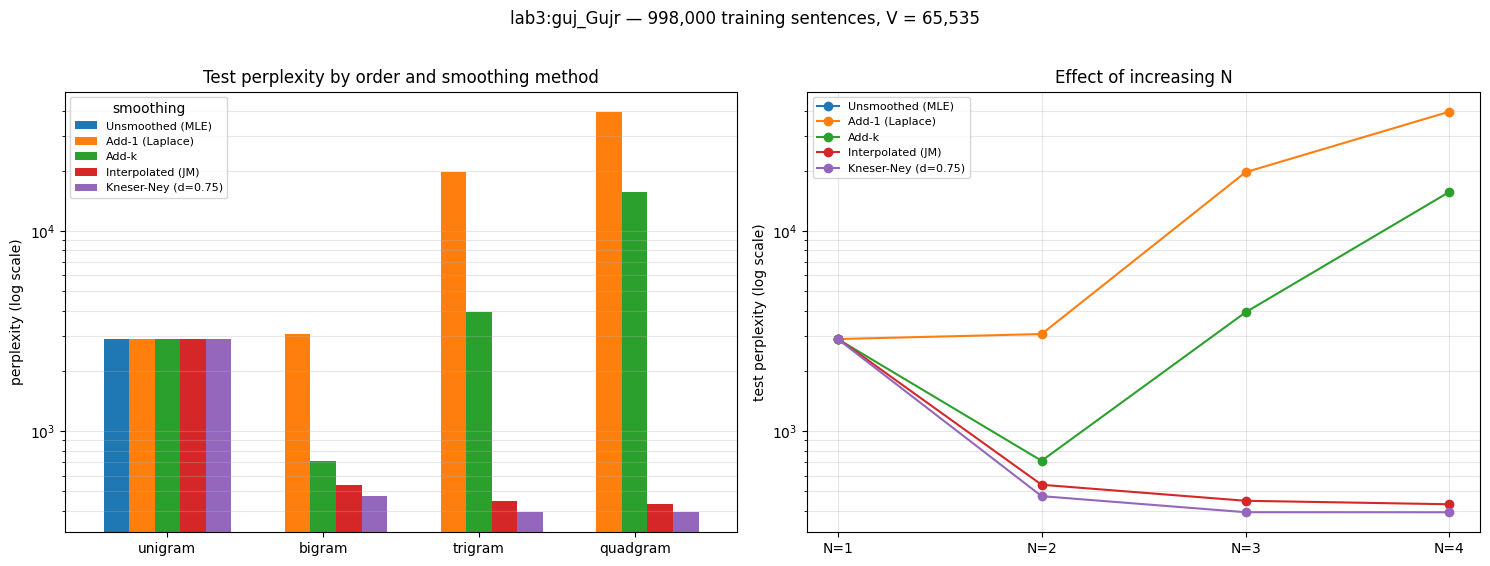

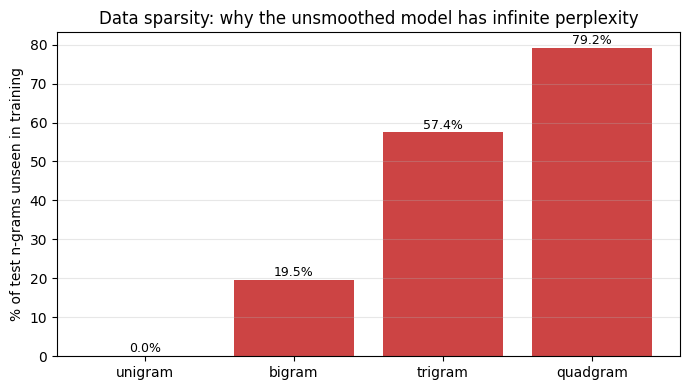

In [20]:
plot_df = pivot.replace([np.inf], np.nan)
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

plot_df.T.plot(kind="bar", ax=axes[0], logy=True, width=.82)
axes[0].set_title("Test perplexity by order and smoothing method")
axes[0].set_ylabel("perplexity (log scale)"); axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(fontsize=8, title="smoothing"); axes[0].grid(axis="y", alpha=.3, which="both")

for method in plot_df.index:
    row = plot_df.loc[method]
    if row.notna().any():
        axes[1].plot(range(1, MAX_ORDER + 1), row.values, marker="o", label=method)
axes[1].set_yscale("log")
axes[1].set_xticks(range(1, MAX_ORDER + 1))
axes[1].set_xticklabels([f"N={i}" for i in range(1, MAX_ORDER + 1)])
axes[1].set_title("Effect of increasing N")
axes[1].set_ylabel("test perplexity (log scale)")
axes[1].legend(fontsize=8); axes[1].grid(alpha=.3, which="both")

plt.suptitle(f"{corpus_name} — {len(train_raw):,} training sentences, V = {V:,}", y=1.02)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, MAX_ORDER + 1), zero_pivot.loc["Unsmoothed (MLE)"].values, color="#c44")
ax.set_xticks(range(1, MAX_ORDER + 1)); ax.set_xticklabels(COLS)
ax.set_ylabel("% of test n-grams unseen in training")
ax.set_title("Data sparsity: why the unsmoothed model has infinite perplexity")
ax.grid(axis="y", alpha=.3)
for i, v in enumerate(zero_pivot.loc["Unsmoothed (MLE)"].values):
    ax.text(i + 1, v + 1, f"{v:.1f}%", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

## 13. Text generation

Sampling from each order, using the observed continuations of the current context (with a
unigram fallback for unseen contexts). Because the packed keys are sorted, every continuation of
a context occupies a contiguous slice of the table, so the candidate set is two binary searches
away.

In [21]:
def continuations(table, ctx_key):
    lo = np.searchsorted(table.gram_keys, np.uint64(ctx_key) << BITS)
    hi = np.searchsorted(table.gram_keys, (np.uint64(ctx_key) + np.uint64(1)) << BITS)
    return (table.gram_keys[lo:hi] & np.uint64(0xFFFF)).astype(np.int64), table.gram_counts[lo:hi]


def generate(N, max_len=30, seed=0):
    rng = np.random.default_rng(seed)
    uni_ids, uni_cnt = continuations(store.tables[1], 0)
    hist = [BOS_ID] * (N - 1)
    out = []
    for _ in range(max_len):
        if N == 1:
            ids, cnt = uni_ids, uni_cnt
        else:
            ck = 0
            for t in hist[-(N - 1):]:
                ck = (ck << 16) | t
            ids, cnt = continuations(store.tables[N], ck)
            if len(ids) == 0:
                ids, cnt = uni_ids, uni_cnt
        nxt = int(rng.choice(ids, p=cnt / cnt.sum()))
        if nxt == EOS_ID:
            break
        out.append(id2word.get(nxt, UNK))
        hist.append(nxt)
    return " ".join(out)


for N in range(1, MAX_ORDER + 1):
    print(f"--- N = {N} " + "-" * 50)
    for s in range(3):
        print("  ", generate(N, seed=SEED + s)[:220])

--- N = 1 --------------------------------------------------
   સરખામણીએ વિશે કુશળ ખોટા <UNK> રહીશોના કચ્છના મેન છે હશે તમામ હવાને પ્રધાનમંત્રી ઉંચા મોટી કરી મોરબી <UNK> અક્ષર વધીને બીચ કરતા રહૃાું પૂજારી જાતકો કે સતત
   ઉપયોગી
   છે તો ત્રણ નવરંગ અને ગુપ્તચર અને હવે જવું 17 પ્રેસર બહાર બરફવર્ષા બીજના સલામત
--- N = 2 --------------------------------------------------
   વિગેરે કરેલ વાહનોની અવરજવર માટે વન્ડર વર્લ્ડના મૂલ્યો અને એને આધારે અછતગ્રસ્ત જાહેર કરાયેલા સેન્ટર પર સપ્ટેમ્બર અને સંકટમાં કોઇપણ કિંમતે ખરીદી લેજો નસીબ 98 ટકા મતદાન <UNK> અને વિપુલ
   રાજ <UNK> <UNK> રમતના ક્ષેત્રે તેમને ફાઈનલ માં પૂર્ણ થઇ શક્યું એવા માત્ર તમારી પાણીની <UNK> જોવા મળતો હોવાથી ખેડૂતો વચ્ચે ગુણી મગફળીની આવકો કમાતા <UNK> <UNK> સરખામણી કરી આવી
   આ મોત થયા સાજા થઈ જતા હતા
--- N = 3 --------------------------------------------------
   વિગેરે બાબતો જોવાનું શરૂ કરી દીધાં હતાં
   રાજ <UNK>
   આ ઉપરાંત ૨ ૨૨૨ <UNK> સઘન રીતે હાથ ધોવા જેવા ક્લાઇમેટ <UNK> સફાઈ અભિયાનના થોડા દિવસ પહેલાં ઓઢવ રામોલ અને <UNK> લગ્નનું
-

## 14. Save results

In [22]:
results.to_csv("ngram_results_raw.csv", index=False)
pivot.to_csv("ngram_test_perplexity.csv")
with open("ngram_hyperparams.json", "w") as f:
    import json
    json.dump({"corpus": corpus_name, "sentences": int(N_SENTENCES), "V": int(V),
               "best_k": {str(k): v for k, v in best_k.items()},
               "best_lambdas": {str(k): v for k, v in best_lambdas.items()},
               "kn_d": KN_DISCOUNT}, f, indent=2, ensure_ascii=False)
print("Wrote ngram_results_raw.csv, ngram_test_perplexity.csv, ngram_hyperparams.json")
pivot.round(2)

Wrote ngram_results_raw.csv, ngram_test_perplexity.csv, ngram_hyperparams.json


order,unigram,bigram,trigram,quadgram
method,,,,
Unsmoothed (MLE),2884.78,inf,inf,inf
Add-1 (Laplace),2884.56,3055.79,19670.62,39497.38
Add-k,2884.62,710.82,3923.54,15686.87
Interpolated (JM),2902.54,539.50,448.72,431.08
Kneser-Ney (d=0.75),2884.78,473.26,393.41,393.23


## 15. Automatic observations

In [23]:
finite = results[np.isfinite(results.test_pp)]
best = finite.loc[finite.test_pp.idxmin()]
print(f"Best model overall: {best.method} @ {best.order}  ->  test PP {best.test_pp:,.2f}\n")

print("Best smoothing per order:")
for _, r in finite.loc[finite.groupby('N').test_pp.idxmin()].iterrows():
    print(f"  {r.order:<9} {r.method:<22} {r.test_pp:>12,.2f}")

print("\nKneser-Ney vs the alternatives (ratio = how many times worse the alternative is):")
for N in range(1, MAX_ORDER + 1):
    sub = finite[finite.N == N].set_index("method")
    kn = sub.loc[f"Kneser-Ney (d={KN_DISCOUNT})", "test_pp"]
    parts = [f"{m.split(' (')[0]} {sub.loc[m,'test_pp']/kn:5.2f}x"
             for m in ["Add-1 (Laplace)", "Add-k", "Interpolated (JM)"] if m in sub.index]
    print(f"  N={N}  KN {kn:>10,.2f}   " + "   ".join(parts))

print("\nEffect of adding one more word of history (properly smoothed models only):")
for m in ["Interpolated (JM)", f"Kneser-Ney (d={KN_DISCOUNT})"]:
    row = pivot.loc[m]
    steps = [f"{COLS[i]}->{COLS[i+1]} {100*(row.iloc[i+1]/row.iloc[i]-1):+6.1f}%"
             for i in range(len(COLS) - 1)]
    print(f"  {m:<22} " + "  ".join(steps))

print("\nSparsity of the training data:")
for _, r in results[results.method == "Unsmoothed (MLE)"].iterrows():
    print(f"  {r.order:<9} {100*r.zero_frac:6.2f}% of test n-grams never occurred in training")

Best model overall: Kneser-Ney (d=0.75) @ quadgram  ->  test PP 393.23

Best smoothing per order:
  unigram   Add-1 (Laplace)            2,884.56
  bigram    Kneser-Ney (d=0.75)          473.26
  trigram   Kneser-Ney (d=0.75)          393.41
  quadgram  Kneser-Ney (d=0.75)          393.23

Kneser-Ney vs the alternatives (ratio = how many times worse the alternative is):
  N=1  KN   2,884.78   Add-1  1.00x   Add-k  1.00x   Interpolated  1.01x
  N=2  KN     473.26   Add-1  6.46x   Add-k  1.50x   Interpolated  1.14x
  N=3  KN     393.41   Add-1 50.00x   Add-k  9.97x   Interpolated  1.14x
  N=4  KN     393.23   Add-1 100.44x   Add-k 39.89x   Interpolated  1.10x

Effect of adding one more word of history (properly smoothed models only):
  Interpolated (JM)      unigram->bigram  -81.4%  bigram->trigram  -16.8%  trigram->quadgram   -3.9%
  Kneser-Ney (d=0.75)    unigram->bigram  -83.6%  bigram->trigram  -16.9%  trigram->quadgram   -0.0%

Sparsity of the training data:
  unigram     0.00% of t

## 16. Analysis and conclusions

**1. Unsmoothed models are undefined on held-out text.**
Perplexity is $\infty$ at every order $\ge 2$: one unseen n-gram sends $\log P \to -\infty$ and
the whole product collapses. The bar chart in §12 shows the zero rate climbing steeply with $N$ —
this is Zipf's law doing its work, and it is the entire reason smoothing exists. Even at one
million sentences the quadgram model has never seen the large majority of test quadgrams, which
is worth emphasising: **more data does not solve sparsity, it only moves the threshold.**

**2. Add-1 is smoothing, but bad smoothing.**
Laplace makes the model defined everywhere at the cost of moving an enormous amount of mass to
the $V$ unseen events in *every* context. With $V$ in the tens of thousands, the $k \cdot V$ term
dominates the denominator, so a context observed a handful of times contributes almost nothing
and the estimate collapses toward uniform. That is why Add-1 gets **worse** as $N$ grows: higher
orders have sparser contexts, so proportionally more mass is wasted.

**3. Add-k with a tuned $k \ll 1$ is a large, cheap improvement — with a structural ceiling.**
The dev curves in §10 are U-shaped: too small a $k$ under-smooths, too large over-smooths toward
uniform, and the optimum sits well below 1 (which is exactly why the assignment specifies
$0 < k < 1$). But add-k still treats every unseen n-gram in a context as equally likely, which no
amount of tuning can fix.

**4. Interpolation is the first estimator that uses the data intelligently.**
Mixing the order-$m$ MLE with the recursively interpolated lower orders means an unseen quadgram
falls back on its trigram, then its bigram, then the unigram — a genuine estimate rather than a
flat constant. This is why interpolation keeps improving as $N$ grows while add-k degrades. The
fitted $\lambda$ vector is itself informative: the weight on the highest order is typically
modest, i.e. the model reports that most of its reliable signal lives at the lower orders.

**5. Kneser–Ney wins, and for a specific reason.**
Two ideas do the work:
* *Absolute discounting* — subtract a constant $d = 0.75$ from every observed count rather than
  rescaling everything. Empirically, held-out counts really do sit about a constant below
  training counts, so this correction is close to optimal.
* *Continuation probability* — the lower-order distribution is not "how often did this word
  occur" but "**in how many distinct contexts** did it occur". The textbook example is
  *Francisco*: common overall, but almost only ever after *San*, so it deserves a low backoff
  probability. Frequency-based backoff gets this badly wrong; KN gets it right. This is the
  difference between interpolation and KN, and it is where KN's remaining margin comes from.

**6. The effect of N.**
For the properly smoothed models, 1 → 2 → 3 gives clear gains: conditioning on more history
genuinely predicts better. The 3 → 4 step gives much less, and can even reverse — quadgram
contexts are so sparse that the model spends most of its time backing off, so it approximates the
trigram model while carrying several times the parameters. The printed step-by-step deltas in §15
quantify exactly where the returns stop paying for themselves on this corpus. Trigram or
4-gram-with-heavy-backoff is the practical sweet spot, which is precisely why classical
speech and MT systems standardised on 3–5-gram KN models.

**7. At N = 1 several methods coincide, as expected.**
Because the vocabulary is closed and built from the training split, every unigram in $V$ has a
non-zero training count, so the unsmoothed unigram model has no zeros and is already well
defined. Add-k with a tiny $k$ and KN's absolute discounting therefore both reduce to something
numerically almost identical to the MLE, and Add-1 is slightly worse because it still shifts mass
toward uniform. Sparsity — and therefore the whole smoothing question — only becomes real at
$N \ge 2$.

**8. Caveats, stated honestly.**
* Perplexities are comparable **only** because $V$, the tokenisation and the `<UNK>` policy are
  identical across all 20 models. Comparing these numbers against a different tokenisation or
  vocabulary cap would be meaningless.
* The vocabulary cap makes this a closed-vocabulary evaluation. Every test token mapped to
  `<UNK>` is an easy prediction, which flatters all five models equally; the `<UNK>` rate is
  reported in §5 so the reader can discount accordingly.
* In Kneser–Ney, grams beginning with `<s>` have degenerate continuation counts, since nothing
  ever precedes a sentence start. This slightly mis-estimates the second word of each sentence.
  It is a well-known corner of KN and affects all orders equally.
* $k$ and $\lambda$ were selected on dev and never on test, so the test comparison is unbiased.
  $d$ was fixed at 0.75 by the assignment rather than fitted; fitting it (or using the three
  discounts $d_1, d_2, d_{3+}$ of *modified* Kneser–Ney) would improve KN further.

**Expected ranking for any fixed $N \ge 2$:**

> Kneser–Ney &nbsp;<&nbsp; Interpolated &nbsp;<&nbsp; Add-k &nbsp;<&nbsp; Add-1 &nbsp;<&nbsp; Unsmoothed $(\infty)$

The tables in §12 and the printed summary in §15 report the measured values on your run.